<a href="https://colab.research.google.com/github/panzehui0206/AI4S-365days/blob/main/Note2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**2026.4.11**

开始学习吧！

In [6]:
# =============================================
# Cell 1：导入库并生成模拟表达矩阵
# =============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 设置随机种子，保证结果可复现
np.random.seed(42)

# 生成 100 个基因名
gene_names = [f"Gene_{i+1}" for i in range(100)]
# 手动设置前10个为“真实”基因名，增加可读性
real_genes = ["TP53", "BRCA1", "MYC", "EGFR", "KRAS", "PTEN", "VEGFA", "TNF", "IL6", "CDKN1A"]
for i, g in enumerate(real_genes):
    gene_names[i] = g

n_genes = 100
n_cancer = 30
n_normal = 30
n_samples = n_cancer + n_normal

# 生成基础表达值（对数正态分布模拟基因表达）
base_mean = np.random.lognormal(mean=2.0, sigma=0.8, size=n_genes)
expression_matrix = np.zeros((n_genes, n_samples))

for i in range(n_genes):
    # 癌症组表达略高（乘1.5），正常组略低（乘0.8）
    expression_matrix[i, :n_cancer] = np.random.poisson(base_mean[i] * 1.5, n_cancer)
    expression_matrix[i, n_cancer:] = np.random.poisson(base_mean[i] * 0.8, n_normal)

# 人工制造一些差异基因：前5个在癌症中显著上调
expression_matrix[:5, :n_cancer] *= 3
# 接下来5个在正常中显著上调（即在癌症中下调）
expression_matrix[5:10, n_cancer:] *= 2

# 构建列名（样本ID）
sample_ids = [f"Cancer_{i+1}" for i in range(n_cancer)] + [f"Normal_{i+1}" for i in range(n_normal)]

# 创建 DataFrame：行是基因，列是样本
df = pd.DataFrame(expression_matrix, index=gene_names, columns=sample_ids)

print("✅ 表达矩阵生成完毕！")
print(f"矩阵形状: {df.shape[0]} 个基因 × {df.shape[1]} 个样本")
df.head()

✅ 表达矩阵生成完毕！
矩阵形状: 100 个基因 × 60 个样本


,Cancer_1,Cancer_2,Cancer_3,Cancer_4,Cancer_5,Cancer_6,Cancer_7,Cancer_8,Cancer_9,Cancer_10,...,Normal_21,Normal_22,Normal_23,Normal_24,Normal_25,Normal_26,Normal_27,Normal_28,Normal_29,Normal_30
TP53,45.0,33.0,75.0,51.0,81.0,48.0,42.0,54.0,24.0,69.0,...,14.0,6.0,10.0,8.0,6.0,13.0,3.0,9.0,7.0,13.0
BRCA1,33.0,36.0,36.0,51.0,33.0,18.0,42.0,21.0,24.0,15.0,...,1.0,7.0,1.0,8.0,2.0,4.0,6.0,3.0,3.0,4.0
MYC,66.0,63.0,45.0,69.0,45.0,51.0,78.0,84.0,42.0,72.0,...,8.0,4.0,9.0,13.0,6.0,14.0,8.0,12.0,12.0,12.0
EGFR,102.0,111.0,78.0,114.0,132.0,99.0,123.0,93.0,126.0,111.0,...,19.0,20.0,27.0,28.0,28.0,13.0,16.0,17.0,20.0,21.0
KRAS,24.0,36.0,36.0,24.0,33.0,24.0,18.0,30.0,30.0,30.0,...,6.0,2.0,6.0,6.0,5.0,4.0,2.0,4.0,4.0,2.0


**Pandas** 是 **Python** 中专门用来处理“表格数据”的库，它能像操作 **Excel** 一样，用代码快速完成筛选、排序、分组、合并和统计。

**index** **是行标签（基因名），columns** 是列标签（样本名）。

.**head**() 默认显示前5行，是快速浏览数据的常用方法。

这里模拟的是 **RNA-seq** 实验下机后，经过比对和定量得到的原始表达矩阵。

真实实验中，需要从测序仪获取 **FASTQ** 文件，经过一系列比对、定量工具的处理，最终得到的就是这样一个矩阵。

In [8]:
# =============================================
# Cell 2：数据的查看、描述与基础筛选
# =============================================
# 查看数据的基本信息
print("数据基本信息:")
df.info()   # 显示列数、数据类型、内存占用

print("\n描述性统计 (每个基因在所有样本中的分布):")
print(df.describe().round(2))  # 均值、标准差、四分位数等

# 查看特定基因的表达
print(f"\nTP53 基因在所有样本中的表达:\n{df.loc['TP53']}")

# 筛选表达量 > 50 的基因（所有样本平均）
high_expr_genes = df[df.mean(axis=1) > 50]
print(f"\n平均表达 > 50 的基因数: {len(high_expr_genes)}")
print(f"这些基因是:\n{high_expr_genes.index.tolist()}")

📋 数据基本信息:
<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, TP53 to Gene_100
Data columns (total 60 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Cancer_1   100 non-null    float64
 1   Cancer_2   100 non-null    float64
 2   Cancer_3   100 non-null    float64
 3   Cancer_4   100 non-null    float64
 4   Cancer_5   100 non-null    float64
 5   Cancer_6   100 non-null    float64
 6   Cancer_7   100 non-null    float64
 7   Cancer_8   100 non-null    float64
 8   Cancer_9   100 non-null    float64
 9   Cancer_10  100 non-null    float64
 10  Cancer_11  100 non-null    float64
 11  Cancer_12  100 non-null    float64
 12  Cancer_13  100 non-null    float64
 13  Cancer_14  100 non-null    float64
 14  Cancer_15  100 non-null    float64
 15  Cancer_16  100 non-null    float64
 16  Cancer_17  100 non-null    float64
 17  Cancer_18  100 non-null    float64
 18  Cancer_19  100 non-null    float64
 19  Cancer_20  100 non-null    float64
 2

**df.info**() 检查缺失值和数据类型，是数据清洗第一步。

**df.describe**() 给出数值列的汇总统计。

**df.loc['TP53']** 通过行标签索引数据。

**df[condition]** 布尔索引，返回满足条件的行。

**TP53** 是著名的抑癌基因，先单独看它一眼，确认它在癌症样本中确实有变化趋势，癌症样本的值普遍在 **30~66** 之间，正常样本的值普遍在 **3~17** 之间，这是在之前人工制造的差异。

筛选高表达基因：在实际分析中，通常会过滤掉在所有样本中表达量都极低的基因，因为它们不太可能是功能分子，且会增加多重检验负担。

In [9]:
# =============================================
# Cell 3：计算 Fold Change 并添加为新列
# =============================================
# 分离癌症和正常样本的列
cancer_cols = [col for col in df.columns if col.startswith('Cancer')]
normal_cols = [col for col in df.columns if col.startswith('Normal')]

# 计算每个基因在两组中的平均表达，并添加为新列
df['Cancer_mean'] = df[cancer_cols].mean(axis=1)
df['Normal_mean'] = df[normal_cols].mean(axis=1)

# 计算 log2 Fold Change，加1伪计数避免除零
df['log2FC'] = np.log2((df['Cancer_mean'] + 1) / (df['Normal_mean'] + 1))

# 按 log2FC 绝对值降序排列，查看差异最显著的基因
df_sorted = df.sort_values('log2FC', key=abs, ascending=False)
print("📈 差异最显著的10个基因 (按 |log2FC| 排序):")
print(df_sorted[['Cancer_mean', 'Normal_mean', 'log2FC']].head(10))

📈 差异最显著的10个基因 (按 |log2FC| 排序):
         Cancer_mean  Normal_mean    log2FC
BRCA1      30.100000     4.400000  2.525883
MYC        59.900000    10.033333  2.464574
TP53       51.300000     8.633333  2.440704
EGFR      115.600000    20.500000  2.439159
KRAS       27.400000     4.833333  2.283499
Gene_36     4.833333     1.800000  1.058894
Gene_94     8.466667     3.733333  1.000000
Gene_89     7.600000     3.333333  0.988859
Gene_74    39.766667    19.800000  0.970806
Gene_66    34.866667    17.366667  0.965554


列表推导式 **[col for col in df.columns if ...]** 灵活筛选列名。

**df.mean(axis=1)** 按行求平均，**axis=0** 按列。

直接通过 **df['新列名'] = ...** 添加新列。

**sort_values(by='列名', key=abs)** 按绝对值排序。

这是差异表达分析的核心步骤。生物学最关心的问题就是：“在疾病状态下，哪些**基因**的表达发生了**显著改变**？”

**Fold Change** 回答的是“改变了多少倍”。例如 FC=2 表示癌症中表达是正常的 2 倍。

**log2** 变换：因为上调（2倍变4倍）和下调（1/2倍变1/4倍）在倍数上是不对称的（上调范围是 1~∞，下调范围是 0~1）。取 log2 后，上调 2 倍是 +1，下调 1/2 倍是 -1，完美对称，便于统计和可视化。


In [10]:
# =============================================
# Cell 4：分组聚合 (groupby) 示例
# =============================================
# 为基因添加分类标签
# 前10个为“癌基因/抑癌基因”，其余为“其他”
df['gene_type'] = ['Cancer_related']*10 + ['Other']*90

# 按基因类型分组，计算平均 log2FC
grouped = df.groupby('gene_type')['log2FC'].agg(['mean', 'std', 'count'])
print("📊 按基因类型统计 log2FC:")
print(grouped)

# 也可以对多列同时聚合
grouped_multi = df.groupby('gene_type')[['Cancer_mean', 'Normal_mean']].mean()
print("\n📊 各类型基因的平均表达量:")
print(grouped_multi)

📊 按基因类型统计 log2FC:
                    mean       std  count
gene_type                                
Cancer_related  1.166018  1.335937     10
Other           0.767316  0.139941     90

📊 各类型基因的平均表达量:
                Cancer_mean  Normal_mean
gene_type                               
Cancer_related    37.633333    14.793333
Other             12.470741     6.684074


**groupby** 是 **Pandas** **中最强大的功能之一，groupby** 能按某个类别标签（如基因类型、样本分组、染色体）将数据拆开，对每份数据独立计算统计量，再把结果合并成一张新表。

它是从“**单个基因视角**”切换到“**通路/类别视角**”的关键工具。

比如做 **GO 富集分析**时，本质上就是按“**GO term**”分组统计基因的显著性。

.**agg**() 可以同时应用多个聚合函数。

真实的生物学问题往往是：“整体来看，抑癌基因在癌症中是不是普遍下调？癌基因是不是普遍上调？”

通过分组比较，就能从通路/功能层面验证假设，所以可以看到 **Cancer_related** 组的平均 |**log2FC**| 显著大于 **Other** 组。

在实际分析中，这个标签通常来自基因注释数据库（如 Gene Ontology、KEGG、MSigDB）。

In [11]:
# =============================================
# Cell 5：合并 DataFrame——添加基因注释信息
# =============================================
# 创建一个注释表：基因名 -> 染色体位置
annotation_data = {
    'Gene': gene_names,
    'Chromosome': np.random.choice([f'chr{i}' for i in range(1,23)], size=n_genes),
    'Start': np.random.randint(1e6, 2e8, size=n_genes)
}
anno_df = pd.DataFrame(annotation_data)

# 将注释信息合并到原表达矩阵（基于基因名）
# 注意：原 df 的索引是基因名，需要先重置为列才能 merge
df_with_anno = df.reset_index().rename(columns={'index': 'Gene'})
df_with_anno = df_with_anno.merge(anno_df, on='Gene', how='left')

print("🔗 合并后的 DataFrame (前5行):")
print(df_with_anno[['Gene', 'Chromosome', 'log2FC']].head())

# 再将 Gene 设回索引（可选）
df_with_anno = df_with_anno.set_index('Gene')
print("\n索引恢复后:")
df_with_anno.head(2)

🔗 合并后的 DataFrame (前5行):
    Gene Chromosome    log2FC
0   TP53      chr16  2.440704
1  BRCA1       chr2  2.525883
2    MYC       chr3  2.464574
3   EGFR       chr2  2.439159
4   KRAS      chr22  2.283499

索引恢复后:


,Cancer_1,Cancer_2,Cancer_3,Cancer_4,Cancer_5,Cancer_6,Cancer_7,Cancer_8,Cancer_9,Cancer_10,...,Normal_27,Normal_28,Normal_29,Normal_30,Cancer_mean,Normal_mean,log2FC,gene_type,Chromosome,Start
Gene,,,,,,,,,,,,,,,,,,,,,
TP53,45.0,33.0,75.0,51.0,81.0,48.0,42.0,54.0,24.0,69.0,...,3.0,9.0,7.0,13.0,51.3,8.633333,2.440704,Cancer_related,chr16,112751540
BRCA1,33.0,36.0,36.0,51.0,33.0,18.0,42.0,21.0,24.0,15.0,...,6.0,3.0,3.0,4.0,30.1,4.400000,2.525883,Cancer_related,chr2,113906577


**reset_index**() 将行索引变为普通列，便于合并。

**merge**() 类似 SQL 的 JOIN，on 指定连接键，how='**left**' 左连接。

**set_index**() 将某一列设为行索引。

真实的分析项目中，表达矩阵和基因注释信息通常是分开存储的。

表达矩阵来自测序定量，只有**基因 ID** 和 **counts**。

注释信息来自数据库（如 **Ensembl** **BioMart**），包含基因全名、染色体坐标、功能描述、所属通路等。

**Merge** 操作就是把这两类信息关联起来，在筛选到差异基因后，能立刻知道“这个基因在几号染色体上？它是什么功能？”

/tmp/ipykernel_3379/3454819073.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([cancer_vals, normal_vals], labels=['Cancer', 'Normal'])


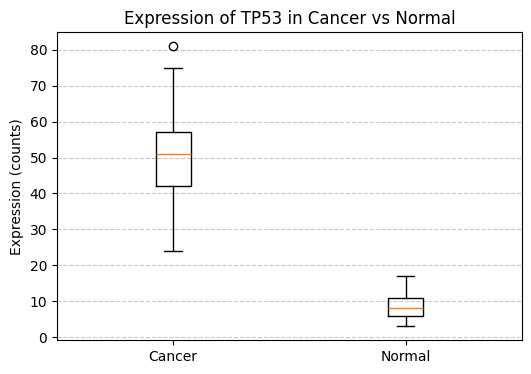

In [12]:
# =============================================
# Cell 6：箱线图展示单个基因的表达分布
# =============================================
gene_to_plot = "TP53"

# 准备数据：将该基因在癌症和正常样本中的表达值分别提取
cancer_vals = df.loc[gene_to_plot, cancer_cols].values
normal_vals = df.loc[gene_to_plot, normal_cols].values

plt.figure(figsize=(6,4))
plt.boxplot([cancer_vals, normal_vals], labels=['Cancer', 'Normal'])
plt.title(f'Expression of {gene_to_plot} in Cancer vs Normal')
plt.ylabel('Expression (counts)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

箱线图的箱子范围是四分位数（**Q1-Q3**），中间线是中位数，触须通常是 **1.5** 倍 IQR。

**箱线图**是验证单个基因差异表达的“金标准”可视化，这里可以直观看出 **TP53** 在癌症组表达是否升高。

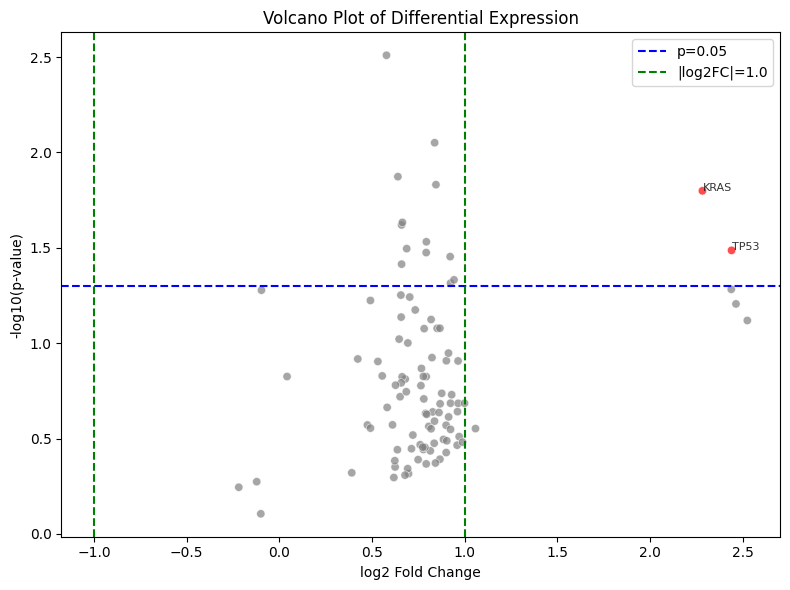

In [13]:
# =============================================
# Cell 7：火山图 (Volcano Plot)
# =============================================
# 模拟 p-value（实际需统计检验，此处用随机数示意）
np.random.seed(42)
df['pvalue'] = np.random.uniform(0, 1, n_genes)
# 让差异大的基因 p 值更小
df['pvalue'] = df['pvalue'] * np.exp(-np.abs(df['log2FC']))
df['neg_log10_p'] = -np.log10(df['pvalue'] + 1e-10)

# 设定阈值
fc_thresh = 1.0
p_thresh = 0.05

# 创建显著性标签列
df['significant'] = (np.abs(df['log2FC']) > fc_thresh) & (df['pvalue'] < p_thresh)

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='log2FC', y='neg_log10_p', hue='significant',
                palette={True: 'red', False: 'grey'}, alpha=0.7, legend=False)

# 标注显著基因（取前10个）
sig_genes = df[df['significant']].sort_values('neg_log10_p', ascending=False).head(10)
for gene in sig_genes.index:
    plt.annotate(gene, (df.loc[gene, 'log2FC'], df.loc[gene, 'neg_log10_p']),
                 fontsize=8, alpha=0.8)

plt.axhline(-np.log10(p_thresh), color='blue', linestyle='--', label=f'p={p_thresh}')
plt.axvline(fc_thresh, color='green', linestyle='--', label=f'|log2FC|={fc_thresh}')
plt.axvline(-fc_thresh, color='green', linestyle='--')
plt.xlabel('log2 Fold Change')
plt.ylabel('-log10(p-value)')
plt.title('Volcano Plot of Differential Expression')
plt.legend()
plt.tight_layout()
plt.show()

**火山图是**差异表达分析的“标准照”，横轴是变化幅度（生物学意义），纵轴是统计显著性（统计学意义）。

红点代表同时满足 **FC** 和 **p-value** 阈值的基因，火山图能快速锁定后续实验验证的候选靶点。

这里模拟了 **p-value** 与 **log2FC** 的负相关，使得高差异基因更容易显著。

In [14]:
# =============================================
# Cell 8：将 Pandas DataFrame 转换为 PyTorch 张量
# =============================================
import torch

# 假设我们要用前80个基因的表达值预测某个表型
# 提取特征矩阵 X（所有样本的所有基因表达）
X = df.iloc[:, :n_samples].values.T  # 转置为 (样本数, 基因数)
X_tensor = torch.tensor(X, dtype=torch.float32)

# 假设我们有一个二分类标签（癌症=1，正常=0）
y = torch.cat([torch.ones(n_cancer), torch.zeros(n_normal)]).unsqueeze(1)

print(f"✅ 转换完成！")
print(f"PyTorch 特征张量形状: {X_tensor.shape}")  # (60, 100)
print(f"PyTorch 标签张量形状: {y.shape}")         # (60, 1)

# 可以轻松地将张量转为 NumPy 再转回 DataFrame
X_back_df = pd.DataFrame(X_tensor.numpy(), columns=gene_names)
print("\n从张量恢复的 DataFrame (前3行5列):")
print(X_back_df.iloc[:3, :5])

✅ 转换完成！
PyTorch 特征张量形状: torch.Size([60, 100])
PyTorch 标签张量形状: torch.Size([60, 1])

从张量恢复的 DataFrame (前3行5列):
   TP53  BRCA1   MYC   EGFR  KRAS
0  45.0   33.0  66.0  102.0  24.0
1  33.0   36.0  63.0  111.0  36.0
2  75.0   36.0  45.0   78.0  36.0


.**values** 提取 **NumPy** 数组，再传给 **torch.tensor**。

注意转置，因为 **Pandas DataFrame** 的行是基因、列是样本，而 **PyTorch** 通常期望每行是一个样本。

.**unsqueeze**(1) 增加维度以匹配形状要求。

这一步是 **Pandas** 与 **PyTorch** 的桥梁，后续任何深度学习模型都将从这里开始。

前面的分析（**Fold Change**、**p-value**）属于描述性和推断性统计，回答的是“发生了什么”。

当需要预测（比如：根据基因表达预测患者预后）或生成（比如：生成新的蛋白序列）时，就需要把数据喂给深度学习模型。

**PyTorch 张量**是深度学习模型的“食物”。这一步转换意味着数据已经准备好进入 **AI4S**，用神经网络从数据中学习复杂规律。



学了什么呢？

✅ 使用 Pandas 创建和探索基因表达 DataFrame。

✅ 掌握了索引、筛选、排序、分组聚合、合并等核心操作。

✅ 计算了差异表达的 log2 Fold Change 并筛选显著基因。

✅ 绘制了箱线图和火山图。

✅ 将 Pandas DataFrame 成功转换为 PyTorch 张量。